In [1]:
#Importing necessary Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [5]:
#Using Panda Library to import & read .csv file
df_data = pd.read_csv('/content/climate_resilient_road_maintenance.csv')

In [6]:
#Setup variables/ Filtering the Dataset
target = 'maintenance_frequency'
features_to_drop = ['road_id', 'timestamp', 'location_lat', 'location_lon', 'maintenance_required', 'maintenance_cost']
X = df_data.drop(columns=features_to_drop + [target], errors='ignore')
y = df_data[target]

In [7]:
#Differentiating between integer and string
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns
#Preprocessing the Dataset to fill the missing data in dataset
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

In [8]:
#split Data for training and testing (20% used for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#initializing Linear Regression model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('model', LinearRegression())])
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['surface_temperature', 'surface_humidity', 'precipitation_rate',
       'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed',
       'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio',
       'extreme_weather_event'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['terrain_type'], dtype='object'))])),
                ('model', LinearRegression())])

In [10]:
#predicting the maintenance frequency
y_pred = model.predict(X_test)

In [11]:
#calculate evaluation metrics (implementation Analysis)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
#Printing the result from Linear Regression
print("=== Model (Linear Regression) Evaluation Results ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

=== Model (Linear Regression) Evaluation Results ===
Mean Absolute Error (MAE): 1.2164
Root Mean Squared Error (RMSE): 1.4173
R² Score: -0.0005


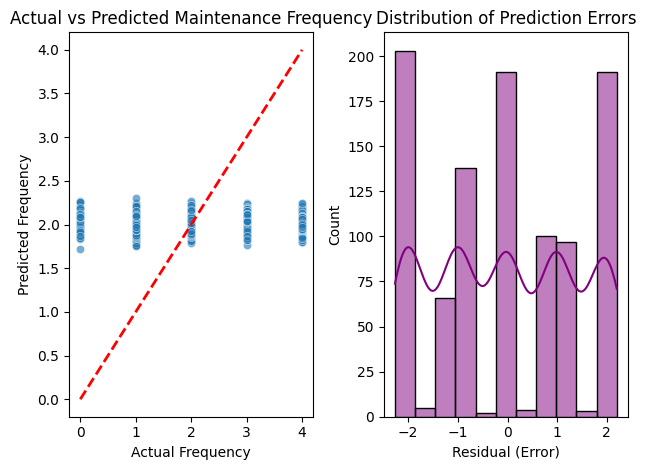


=== Top Factors Influencing Maintenance (Linear Model) ===
                      Factor  Importance
10     extreme_weather_event    0.046257
11         terrain_type_flat    0.023956
13  terrain_type_mountainous   -0.022900
2         precipitation_rate    0.007119
4              pothole_depth    0.005652


In [13]:
#Plot 1: Scatter plot for maintenance frequency
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residuals (Errors)
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

# Getting feature names back for interpretation
feature_names = list(numerical_cols) + \
    list(model.named_steps['preprocessor'].named_transformers_['cat']
         .named_steps['onehot'].get_feature_names_out(categorical_cols))
# Top Factors influencing the prediction of maintenance frequecy
coefs = pd.DataFrame({
    'Factor': feature_names,
    'Importance': model.named_steps['model'].coef_
})
coefs['Absolute_Impact'] = coefs['Importance'].abs()
coefs = coefs.sort_values(by='Absolute_Impact', ascending=False)

print("\n=== Top Factors Influencing Maintenance (Linear Model) ===")
print(coefs[['Factor', 'Importance']].head(5))

In [14]:
#introducing Random Forest model
model_2 = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', RandomForestRegressor(n_estimators=100, random_state=42))])

In [15]:
#training the Random Forest Regression model
model_2.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['surface_temperature', 'surface_humidity', 'precipitation_rate',
       'crack_density', 'pothole_depth', 'roughness_index', 'wind_speed',
       'solar_radiation', 'vehicle_count', 'heavy_vehicle_ratio',
       'extreme_weather_event'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['terrain_type'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [16]:
#predicting the maintenance frequency for Random forest regression(model 2)
y_pred_model_2 = model_2.predict(X_test)

In [17]:
# Evaluating and printing result for model 2
mae = mean_absolute_error(y_test, y_pred_model_2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_model_2))
r2 = r2_score(y_test, y_pred_model_2)
print("=== Model 2 (Random Forest Regressor) Evaluation Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

=== Model 2 (Random Forest Regressor) Evaluation Metrics ===
Mean Absolute Error (MAE): 1.2365
Root Mean Squared Error (RMSE): 1.4311
R-squared (R2): -0.0200



=== Top Factors Affecting Road Maintenance (Random Forest) ===
            Feature  Importance
   surface_humidity    0.102065
 precipitation_rate    0.101037
surface_temperature    0.097660
heavy_vehicle_ratio    0.096954
      crack_density    0.096440
         wind_speed    0.095718
      vehicle_count    0.094522
    solar_radiation    0.094500
      pothole_depth    0.093728
    roughness_index    0.093398


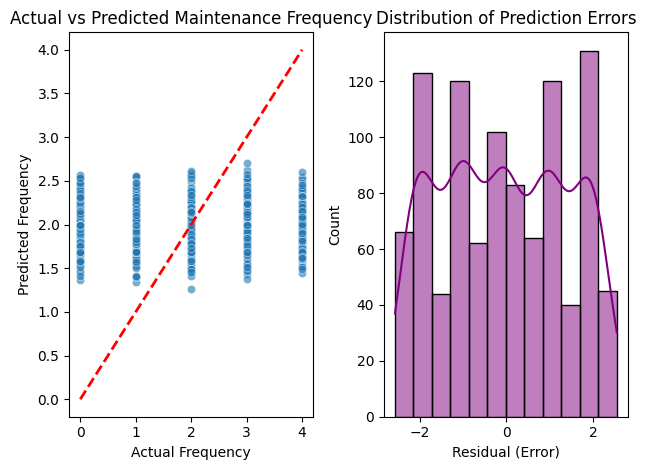

In [18]:
# Getting feature names back for interpretation
ohe = (model_2.named_steps['preprocessor']
       .named_transformers_['cat']
       .named_steps['onehot'])
feature_names = list(numerical_cols) + list(ohe.get_feature_names_out(categorical_cols))
# Feature importance for model 2
importances = model_2.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\n=== Top Factors Affecting Road Maintenance (Random Forest) ===")
print(feature_imp_df.head(10).to_string(index=False))

# Plot 1: Scattered Plot for maintenance frequency prediction
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_model_2, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residual Plot
residuals = y_test - y_pred_model_2
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

Random forest regression also shows -ve value of R2, which means it also performed poorly ans the residual value was also high

In [19]:
from sklearn.ensemble import GradientBoostingRegressor

In [20]:
#Initializing the Gradient boost Regression
gbr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # Using more estimators and a slightly deeper tree for better complexity capture
    ('model', GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42))
])

# 5. Train and Evaluate
gbr_model.fit(X_train, y_train)
y_pred_gbr = gbr_model.predict(X_test)

# 6. Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred_gbr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2 = r2_score(y_test, y_pred_gbr)

print("=====================================================")
print("Gradient Boosting Regressor Evaluation")
print("=====================================================")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Gradient Boosting Regressor Evaluation
Mean Absolute Error (MAE): 1.2389
Root Mean Squared Error (RMSE): 1.4362
R-squared (R2): -0.0273


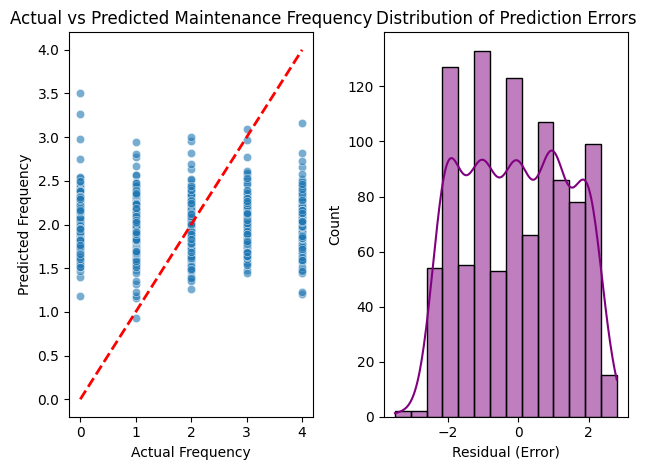

In [21]:
# plot 2: Scatter plot for Maintenance frequency
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_gbr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Frequency")
plt.ylabel("Predicted Frequency")
plt.title("Actual vs Predicted Maintenance Frequency")

# Plot 2: Residuals (Errors)
residuals = y_test - y_pred_gbr
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel("Residual (Error)")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [22]:
# Getting feature names back for interpretation
ohe = (gbr_model.named_steps['preprocessor']
       .named_transformers_['cat']
       .named_steps['onehot'])
feature_names = list(numerical_cols) + list(ohe.get_feature_names_out(categorical_cols))

# Extract importance scores from the trained model
importances = gbr_model.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
# Sort the factors by importance score
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("=====================================================")
print("Top 10 Factors Influencing Maintenance Frequency")
print("(Based on Gradient Boosting Feature Importance Score)")
print("=====================================================")
print(feature_imp_df.head(10).to_string(index=False))

Top 10 Factors Influencing Maintenance Frequency
(Based on Gradient Boosting Feature Importance Score)
            Feature  Importance
   surface_humidity    0.118263
 precipitation_rate    0.111706
surface_temperature    0.110647
heavy_vehicle_ratio    0.109782
         wind_speed    0.098698
      crack_density    0.093601
    solar_radiation    0.091955
    roughness_index    0.088240
      pothole_depth    0.085620
      vehicle_count    0.074382


In [23]:
#Checking if dataset is balanced for maintenance required for classification method
df_data['maintenance_required'].value_counts()

,count
maintenance_required,
1,4581
0,419


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

#Skimming our dataset
EXCLUDE_COLS = ['road_id', 'timestamp', 'location_lat', 'location_lon', 'maintenance_frequency', 'maintenance_required', 'maintenance_cost']

all_features = [col for col in df_data.columns if col not in EXCLUDE_COLS]
numerical_cols = [col for col in all_features if df_data[col].dtype in ['int64', 'float64']]
categorical_cols = [col for col in all_features if df_data[col].dtype == 'object']


# Handling missing values for numerical values
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
# Handling missing values for category values
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
#Preprocessing the Dataset
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop' # Drop any columns not specified above
)

# Getting all feature names after preprocessing
def get_feature_names(model, numerical_cols, categorical_cols):
    ohe = (
        model.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['onehot']
    )
    return list(numerical_cols) + list(ohe.get_feature_names_out(categorical_cols))




print("\n\n====================================================================")
print("Random Forest Classifier")
print("====================================================================")

#training the Dataset
target_cls = 'maintenance_required'
X_cls = df_data[numerical_cols + categorical_cols] # Features are already pre-selected by EXCLUDE_COLS
y_cls = df_data[target_cls]
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# Define and Train Random Forest Classification Model
rf_classifier = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
rf_classifier.fit(X_train_cls, y_train_cls)

# Predict and Evaluate
y_probs = rf_classifier.predict_proba(X_test_cls)[:, 1]
y_pred_cls = rf_classifier.predict(X_test_cls)
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls, target_names=['No Maintenance (0)', 'Maintenance Required (1)']))

# Feature Importance
feature_names_cls = get_feature_names(rf_classifier, numerical_cols, categorical_cols)
importances = rf_classifier.named_steps['model'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names_cls, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\nTop 10 Factors for Maintenance Requirement (Classification):")
print(feature_imp_df.head(10).to_string(index=False))




Random Forest Classifier
Accuracy: 0.9970

Classification Report:
                          precision    recall  f1-score   support

      No Maintenance (0)       0.99      0.98      0.98        84
Maintenance Required (1)       1.00      1.00      1.00       916

                accuracy                           1.00      1000
               macro avg       0.99      0.99      0.99      1000
            weighted avg       1.00      1.00      1.00      1000


Top 10 Factors for Maintenance Requirement (Classification):
              Feature  Importance
        pothole_depth    0.350331
        crack_density    0.254681
      roughness_index    0.133896
extreme_weather_event    0.080164
  heavy_vehicle_ratio    0.036791
        vehicle_count    0.035890
           wind_speed    0.022824
  surface_temperature    0.020350
   precipitation_rate    0.019913
     surface_humidity    0.019834


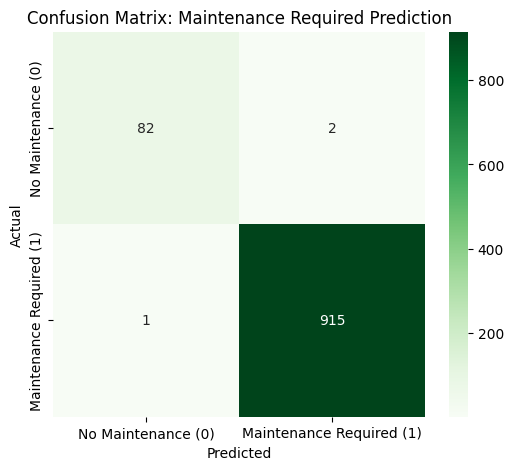

In [ ]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
#plot 1: confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,               # Annotate cells with the numbers
    fmt='d',                  # Format numbers as integers (d for decimal)
    cmap='Greens',            # Color map used in your image (or a similar green)
    xticklabels=['No Maintenance (0)', 'Maintenance Required (1)'],
    yticklabels=['No Maintenance (0)', 'Maintenance Required (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Maintenance Required Prediction')
plt.show()

/tmp/ipython-input-1589167529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='rocket')


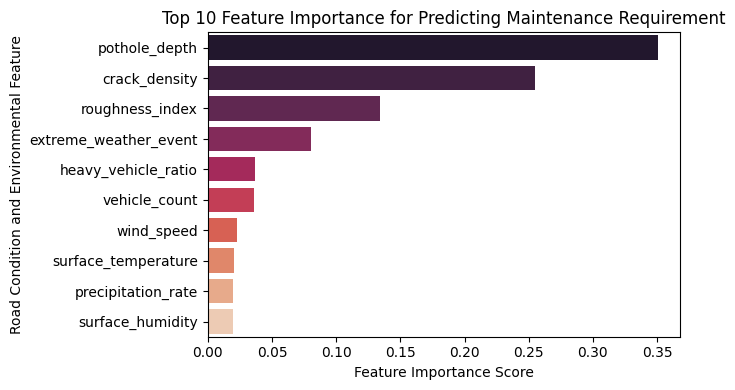

In [25]:
# Plot 2: Feature Importance Plot
plt.figure(figsize=(7, 4)) # Set plot size
# Using the top 10 features for clear visualization
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='rocket')
plt.title('Top 10 Feature Importance for Predicting Maintenance Requirement')
plt.xlabel('Feature Importance Score')
plt.ylabel('Road Condition and Environmental Feature')
plt.tight_layout()
plt.show()

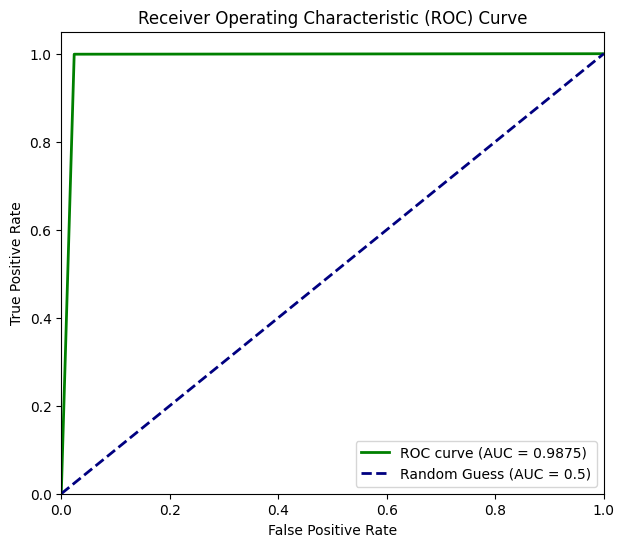

ROC AUC Score: 0.9875


In [26]:
from sklearn.metrics._plot.roc_curve import roc_curve
from sklearn.metrics import auc
# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test_cls, y_pred_cls)
# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)
#plot 3: ROC curve
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
print(f"ROC AUC Score: {roc_auc:.4f}")

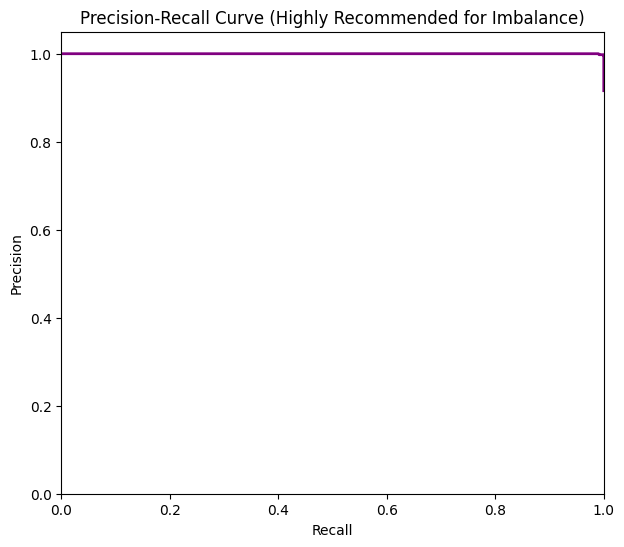

In [27]:
# Calculate precision, recall, and thresholds
precision, recall, _ = precision_recall_curve(y_test_cls, y_probs)
# Plot 4: PR curve
plt.figure(figsize=(7, 6))
plt.plot(recall, precision, color='purple', lw=2, label='Precision-Recall curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Highly Recommended for Imbalance)')
plt.show()

In [28]:
# Extract the classifier model from the pipeline (preprocessor handles features)
estimator = rf_classifier.named_steps['model']
X_transformed = rf_classifier.named_steps['preprocessor'].fit_transform(X_cls)


In [29]:
# Calculate scores on training and cross-validation sets
train_sizes, train_scores, test_scores = learning_curve(
    estimator, X_transformed, y_cls, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', random_state=42
)


In [30]:
# Calculate mean and standard deviation for scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)


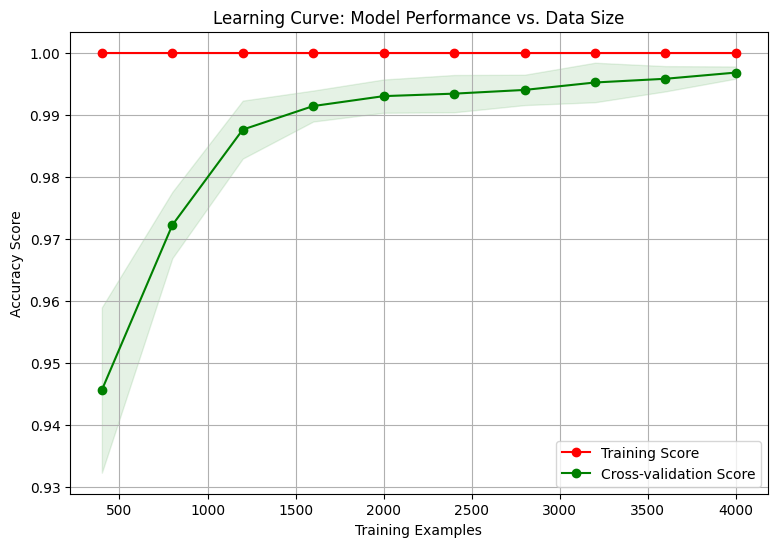

In [31]:
#plotting a learning curve
plt.figure(figsize=(9, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation Score")

plt.xlabel("Training Examples")
plt.ylabel("Accuracy Score")
plt.title("Learning Curve: Model Performance vs. Data Size")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [33]:
# --- FINAL VALIDATION (Confusion Matrix and Accuracy) ---
cm = confusion_matrix(y_test_cls, y_pred_cls)
print("\nFinal Confusion Matrix:")
print(cm)
print(f"Final Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.4f}")


Final Confusion Matrix:
[[ 82   2]
 [  1 915]]
Final Accuracy: 0.9970
